In [ ]:
# using ARXIV Articles dataset

# load data from hugging face
from datasets import load_dataset
dataset = load_dataset("maartengr/arxiv_nlp")["train"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/617 [00:00<?, ?B/s]

data.csv:   0%|          | 0.00/53.2M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
# extract metadata
abstracts = dataset["Abstracts"]
titles = dataset["Titles"]

In [ ]:
titles

Column(['Introduction to Arabic Speech Recognition Using CMUSphinx System', 'Arabic Speech Recognition System using CMU-Sphinx4', 'On the Development of Text Input Method - Lessons Learned', 'Network statistics on early English Syntax: Structural criteria', 'Segmentation and Context of Literary and Musical Sequences'])

# A common pipeline for text clustering

In [ ]:
# convert input in embeddings using embedding model
# reduce the dimensionality with dimensionality reduction technique
# find groups of semantically similar documents with a cluster model.

In [ ]:
# faster for inference model - below
from sentence_transformers import SentenceTransformer

# create an embedding for each abstract
embedding_model= SentenceTransformer("thenlper/gte-small")
embeddings = embedding_model.encode(abstracts, show_progress_bar = True)

embeddings.shape

modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/66.7M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

(44949, 384)

# Reducing the dimensionality of Embeddings

In [ ]:
from umap import UMAP

# we reduce the input embeddings from 384 dimensions to 5 dimensions
umap_model = UMAP(
    n_components=5, min_dist=0.0, metric = 'cosine', random_state = 42
)
reduced_embeddings = umap_model.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# Cluster the reduced embeddings

In [ ]:
from hdbscan import HDBSCAN

# we fit the model and extract clusters
hdbscan_model = HDBSCAN(
    min_cluster_size = 50,
    metric = "euclidean",
    cluster_selection_method = "eom"
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
len(set(clusters))

155

In [ ]:
clusters

array([ -1,  -1,  -1, ...,  -1, 133,  -1])

In [ ]:
# inspecting the clusters
import numpy as np

# printig first three documents in cluster 0
cluster = 0
for index in np.where(clusters == cluster)[0][:3]:
  print(abstracts[int(index)][:300] + "... \n")

  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written fo... 

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign lang... 

  Modern computational linguistic software cannot produce important aspects of
sign language translation. Using some researches we deduce that the majority of
automatic sign language translation systems ignore many aspects when they
generate animation; therefore the interpretation lost the truth inf... 



In [ ]:
# to visualize our results we will need to reduce our document embeddings to two embeddings ( for x/y plane)
import pandas as pd

reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric = 'cosine', random_state = 42
).fit_transform(embeddings)

# create dataframe
df = pd.DataFrame(reduced_embeddings, columns = ["x","y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]

# select outliers and non outliers clusters
to_plot = df.loc[df.cluster != "-1", :]
outliers = df.loc[df.cluster == "-1", :]


In [ ]:
to_plot

,x,y,title,cluster
4,4.513205,2.437404,Segmentation and Context of Literary and Music...,85
5,3.366080,0.421517,International Standard for a Linguistic Annota...,97
6,3.342744,0.499340,A Formal Model of Dictionary Structure and Con...,97
8,3.254276,1.290046,Learning Probabilistic Models of Word Sense Di...,101
11,-1.310467,-0.201164,Bio-linguistic transition and Baldwin effect i...,90
...,...,...,...,...
44937,3.259644,1.295265,Selective Sampling for Example-based Word Sens...,101
44938,0.404549,-1.648838,Practical experiments with regular approximati...,117
44939,-4.078432,-0.307945,Question Answering System Using Syntactic Info...,87
44941,-0.487588,-3.247160,Resolution of Indirect Anaphora in Japanese Se...,11


(np.float64(-8.334335255622864),
 np.float64(11.817492890357972),
 np.float64(-5.973596382141113),
 np.float64(11.185701179504395))

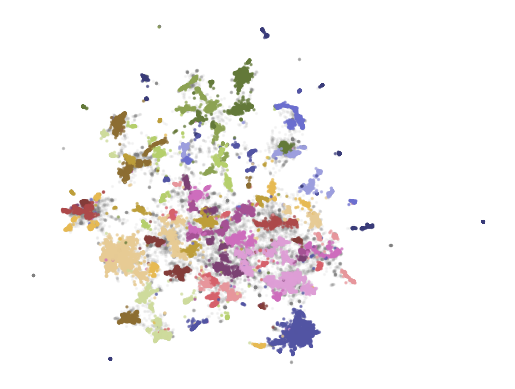

In [14]:
import matplotlib.pyplot as plt

# plot outliers and not outliers separately
plt.scatter(outliers.x, outliers.y, alpha = 0.05, s=2, c="grey")
plt.scatter(to_plot.x, to_plot.y, alpha = 0.6, s=2, c=to_plot.cluster.astype(int), cmap="tab20b")
plt.axis("off")

# From text clustering to Topic Modelling

## BERTopic : Modular topic framework

In [17]:
import sys
if 'bertopic' not in sys.modules:
  !pip install bertopic

# to run BERTopic with our ArXiv dataset, we can use our previously defined models and embeddings( although it is not mandatory)

from bertopic import BERTopic

# train our model with our previosly defined models
topic_model = BERTopic(
    embedding_model = embedding_model,
    umap_model = umap_model,
    hdbscan_model = hdbscan_model,
    verbose = True
).fit(abstracts, embeddings)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 14.0 MB/s eta 0:00:00


2025-12-13 06:41:10,049 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-13 06:42:24,482 - BERTopic - Dimensionality - Completed ✓
2025-12-13 06:42:24,487 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-13 06:42:33,337 - BERTopic - Cluster - Completed ✓
2025-12-13 06:42:33,350 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-13 06:42:37,129 - BERTopic - Representation - Completed ✓


In [18]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,14210,-1_of_the_and_to,"[of, the, and, to, in, we, language, for, that...",[ GPT-$3$ has attracted lots of attention due...
1,0,2316,0_speech_asr_recognition_end,"[speech, asr, recognition, end, acoustic, spea...",[ The speech chain mechanism integrates autom...
2,1,2183,1_question_qa_questions_answer,"[question, qa, questions, answer, answering, a...",[ Text-based Question Generation (QG) aims at...
3,2,941,2_translation_nmt_machine_bleu,"[translation, nmt, machine, bleu, neural, engl...","[ Recently, the development of neural machine..."
4,3,880,3_summarization_summaries_summary_abstractive,"[summarization, summaries, summary, abstractiv...",[ Sentence summarization shortens given texts...
...,...,...,...,...,...
150,149,54,149_sentence_embeddings_sts_embedding,"[sentence, embeddings, sts, embedding, similar...",[ Sentence representation at the semantic lev...
151,150,54,150_gans_gan_adversarial_generation,"[gans, gan, adversarial, generation, generativ...",[ Text generation is of particular interest i...
152,151,54,151_coherence_discourse_paragraph_text,"[coherence, discourse, paragraph, text, cohesi...",[ While there has been significant progress t...
153,152,53,152_chatgpt_its_openai_tasks,"[chatgpt, its, openai, tasks, has, ai, capabil...","[ Over the last few years, large language mod..."


In [20]:
topic_model.get_topic(0)

[('speech', np.float64(0.028208883288593535)),
 ('asr', np.float64(0.018842312810416793)),
 ('recognition', np.float64(0.01351959051292077)),
 ('end', np.float64(0.009745990895354896)),
 ('acoustic', np.float64(0.009384710004108402)),
 ('speaker', np.float64(0.006877359138616964)),
 ('audio', np.float64(0.006785262733110495)),
 ('the', np.float64(0.006370412745274845)),
 ('error', np.float64(0.00634287314665723)),
 ('automatic', np.float64(0.0063065026437668335))]

In [21]:
topic_model.find_topics("topic modelling")

([24, -1, 38, 84, 32],
 [np.float32(0.9469514),
  np.float32(0.9072857),
  np.float32(0.9055518),
  np.float32(0.8997178),
  np.float32(0.8996311)])

In [23]:
topic_model.get_topic(24)

[('topic', np.float64(0.06811153301756999)),
 ('topics', np.float64(0.035746717561104396)),
 ('lda', np.float64(0.016020062969070364)),
 ('latent', np.float64(0.013574936227317968)),
 ('documents', np.float64(0.013201698266173009)),
 ('document', np.float64(0.012912590658853182)),
 ('modeling', np.float64(0.012084716289729468)),
 ('dirichlet', np.float64(0.01010281253111858)),
 ('word', np.float64(0.008653858081603273)),
 ('allocation', np.float64(0.007950503995528465))]

In [25]:
topic_model.topics_[titles.index("BERTopic: Neural topic modeling with a class-based TF-IDF procedure")]

24

In [30]:
# visualize topics and documents
fig = topic_model.visualize_documents(
    list(titles), # Convert titles to a standard Python list
    reduced_embeddings = reduced_embeddings,
    width= 1200,
    hide_annotations = True
)

# update fonts and legends for easier visualization
fig.update_layout(font=dict(size = 16))

Output hidden; open in https://colab.research.google.com to view.

In [31]:
# visualize barchart with ranked keywords
topic_model.visualize_barchart()

In [32]:
# visualize relationships between topics
topic_model.visualize_heatmap(n_clusters=30)

In [33]:
# visualize the potential heirarchical structure of topics
topic_model.visualize_hierarchy()

In [36]:
# it still represents a topic through a bag of words without taking into account semantic structures
# we are going to save our model for easy comparison

from copy import deepcopy
original_topics = deepcopy(topic_model.topic_representations_)

In [37]:
# now let's create a short wrapper that we can use to quickly visualize the differences in topic words to compare
# with or without representation models

def topic_difference(model, original_topics, nr_topics = 5):
  """ show the differences in topic representations between two models"""
  df = pd.DataFrame(columns = ["Topic", "Original", "Updated"])
  for topic in range(nr_topics):
    # extracting top 5 words per topic per model
    og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])
    new_words = " | ".join(list(zip(*model.topic_representations_[topic]))[0][:5])
    df.loc[len(df)] = [topic, og_words, new_words]
  return df

# KeyBERTInspired

In [38]:
from bertopic.representation import KeyBERTInspired

# create a representation model
representation_model = KeyBERTInspired()
topic_model.update_topics(abstracts, representation_model = representation_model)

# show differences
topic_difference(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,phonetic | encoder | transcription | speech | ...
1,1,question | qa | questions | answer | answering,answering | comprehension | questions | questi...
2,2,translation | nmt | machine | bleu | neural,translation | translate | translations | trans...
3,3,summarization | summaries | summary | abstract...,summarization | summarizers | summaries | summ...
4,4,hate | offensive | speech | detection | toxic,hate | hateful | language | offensive | languages


# Maximal Marginal relevance

In [39]:
# we still had redundancy with keybert
# to diversify our representations we can use MMR

from bertopic.representation import MaximalMarginalRelevance

representation_model = MaximalMarginalRelevance(diversity = 0.2)
topic_model.update_topics(abstracts, representation_model = representation_model)

topic_difference(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,speech | asr | audio | error | automatic
1,1,question | qa | questions | answer | answering,questions | retrieval | comprehension | passag...
2,2,translation | nmt | machine | bleu | neural,translation | nmt | bleu | neural | parallel
3,3,summarization | summaries | summary | abstract...,summarization | summaries | extractive | docum...
4,4,hate | offensive | speech | detection | toxic,hate | offensive | toxic | abusive | hateful


# Text Generation Lego Block

In [41]:
from transformers import pipeline
from bertopic.representation import TextGeneration

prompt = """I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Based on the documents and keywords, what is this topic about?"""

# update our representations using Flan-t5
generator = pipeline("text2text-generation", model = "google/flan-t5-small")
representation_model = TextGeneration(generator, prompt=prompt, doc_length = 50, tokenizer = "whitespace")
topic_model.update_topics(abstracts, representation_model = representation_model)

topic_difference(topic_model, original_topics)

Device set to use cuda:0
100%|██████████| 155/155 [02:19<00:00,  1.11it/s]


,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,Speech-to-speech synthesis | | | |
1,1,question | qa | questions | answer | answering,Question answering systems | | | |
2,2,translation | nmt | machine | bleu | neural,Science/Tech | | | |
3,3,summarization | summaries | summary | abstract...,Document summarization | | | |
4,4,hate | offensive | speech | detection | toxic,Science/Tech | | | |


In [46]:
# we can also use openai api to use gpt versions which might perform better ( science/tech )

import sys
if 'datamapplot' not in sys.modules:
  !pip install datamapplot

import datamapplot
# visualize topics and documents
fig = topic_model.visualize_document_datamap(
    titles,
    topics = list(range(20)),
    reduced_embeddings = reduced_embeddings,
    width= 1200
)

NameError: name 'datamapplot' is not defined

In [51]:
fig = topic_model.visualize_documents(
    list(titles), # Convert titles to a standard Pytho
    topics = list(range(10)),
    reduced_embeddings = reduced_embeddings,
    width= 1200,
    hide_annotations = True
)

In [52]:
fig

Output hidden; open in https://colab.research.google.com to view.